# American Express Customer Churn Analysis

## LOAD & UNDERSTAND DATA

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"E:\DATA ANALYTICS\preinsta project\american express\Dataset_master.xlsx - American Express User Exit Pred.csv")

df.head()

,Credit Score,Geography,Gender,Age,Customer Since,Current Account,Num of products,UPI Enabled,Estimated Yearly Income,Closed
0,553,Delhi,Female,45,4,0.000,4,1,274150,0
1,447,Bengaluru,Male,31,7,0.000,4,1,519360,0
2,501,Delhi,Female,32,2,0.000,4,1,545501,0
3,428,Delhi,Male,51,3,0.000,4,1,86868,0
4,492,Delhi,Female,57,6,1912681.501,2,1,518680,0


In [25]:
df.shape

(9927, 10)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9927 entries, 0 to 9926
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Credit Score             9927 non-null   int64  
 1   Geography                9927 non-null   object 
 2   Gender                   9927 non-null   object 
 3   Age                      9927 non-null   int64  
 4   Customer Since           9927 non-null   int64  
 5   Current Account          9927 non-null   float64
 6   Num of products          9927 non-null   int64  
 7   UPI Enabled              9927 non-null   int64  
 8   Estimated Yearly Income  9927 non-null   int64  
 9   Closed                   9927 non-null   int64  
dtypes: float64(1), int64(7), object(2)
memory usage: 775.7+ KB


In [27]:
df.describe()

,Credit Score,Age,Customer Since,Current Account,Num of products,UPI Enabled,Estimated Yearly Income,Closed
count,9927.000000,9927.000000,9927.000000,9.927000e+03,9927.000000,9927.000000,9927.000000,9927.000000
mean,529.465599,45.666163,4.417447,9.839860e+05,3.029314,0.704946,274356.781505,0.204291
std,78.610089,16.100517,2.392987,8.407988e+05,1.081528,0.456090,157578.700489,0.403203
min,285.000000,17.000000,0.000000,0.000000e+00,2.000000,0.000000,32.000000,0.000000
25%,475.000000,35.000000,3.000000,0.000000e+00,2.000000,0.000000,139890.500000,0.000000
50%,531.000000,42.000000,4.000000,1.159221e+06,2.000000,1.000000,274533.000000,0.000000
75%,584.000000,53.000000,7.000000,1.655112e+06,4.000000,1.000000,409437.000000,0.000000
max,692.000000,137.000000,8.000000,3.985304e+06,7.000000,1.000000,547947.000000,1.000000


In [28]:
# Unique values
df.nunique()

Credit Score                377
Geography                     3
Gender                        2
Age                          70
Customer Since                9
Current Account            6326
Num of products               4
UPI Enabled                   2
Estimated Yearly Income    9841
Closed                        2
dtype: int64

In [29]:
df['Geography'].unique()

array(['Delhi', 'Bengaluru', 'Mumbai'], dtype=object)

### The dataset consists of 9927 rows and 10 columns, indicating a moderately large dataset suitable for analysis.The presence of both numerical and categorical variables allows us to analyze customer behavior from multiple dimensions.

## DATA CLEANING

In [30]:
# Missing values

df.isnull().sum()

Credit Score               0
Geography                  0
Gender                     0
Age                        0
Customer Since             0
Current Account            0
Num of products            0
UPI Enabled                0
Estimated Yearly Income    0
Closed                     0
dtype: int64

In [31]:
# FIX COLUMN NAMES 

df.columns = df.columns.str.strip().str.replace(" ", "_")
df = df.rename(columns={'Current_Account':'Current_Account_Balance','Geography':'City','Closed':'Customer_Status'})
df.columns

Index(['Credit_Score', 'City', 'Gender', 'Age', 'Customer_Since',
       'Current_Account_Balance', 'Num_of_products', 'UPI_Enabled',
       'Estimated_Yearly_Income', 'Customer_Status'],
      dtype='object')

In [32]:
# REPLACE 0/1 WITH MEANINGFUL VALUES

df['Customer_Status'] = df['Customer_Status'].map({0: 'Retained', 1: 'Churned'})
df['UPI_Enabled'] = df['UPI_Enabled'].map({0: 'No', 1: 'Yes'})

In [33]:
# group Age

df['Age_Group'] = pd.cut(df['Age'], bins=[18,30,50,137], labels=['Young','Mid','Old'])

### Column names were standardized by removing spaces and replacing them with underscores to improve usability and avoid errors during analysis,and rename it with meaningful column name.also Binary variables were converted into meaningful labels (e.g., Yes/No, Churned/Retained) to enhance readability and make insights more business-friendly.

## univariate analysis

C:\Users\anujm\AppData\Local\Temp\ipykernel_14300\255711749.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cd= sns.countplot(x='Customer_Status', data=df,palette="Set2")


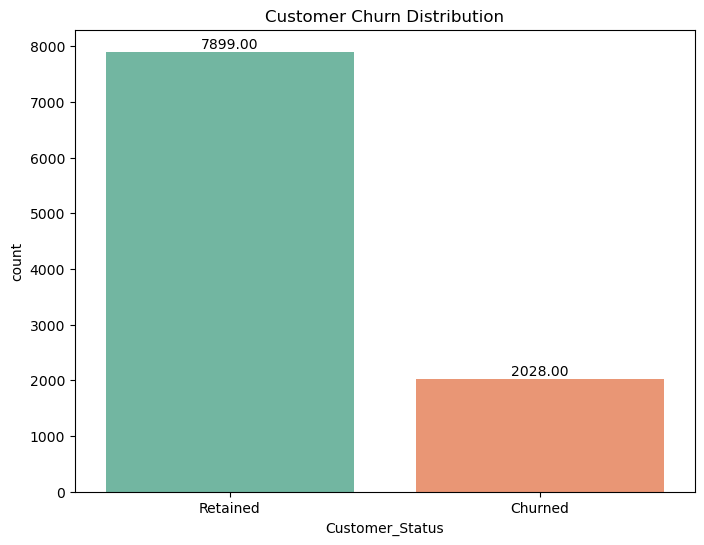

In [34]:
# Churn Distribution analysis

plt.figure(figsize=(8,6))
cd= sns.countplot(x='Customer_Status', data=df,palette="Set2")
plt.title("Customer Churn Distribution")

for i in cd.containers:
    cd.bar_label(i,fmt="%.2f")
    
plt.show()

### INSIGHT:

The chart shows the distribution of retained vs churned customers.
A higher number of retained customers indicates lower churn, but even a small churn percentage can significantly impact business revenue.

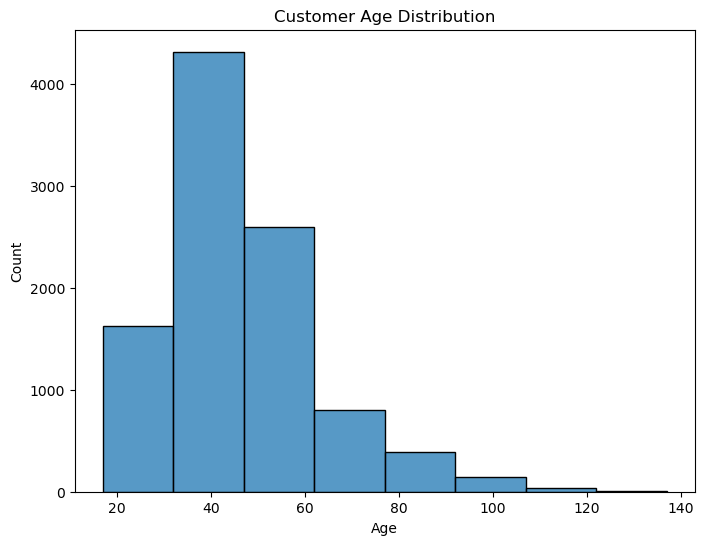

In [35]:
# Age Distribution analysis

plt.figure(figsize=(8,6))
sns.histplot(x='Age', data=df,bins =8)
plt.title("Customer Age Distribution")
    
plt.show()

### Insight:

The majority of customers fall within the 30–50 age range, indicating that middle-aged individuals form the largest customer segment.

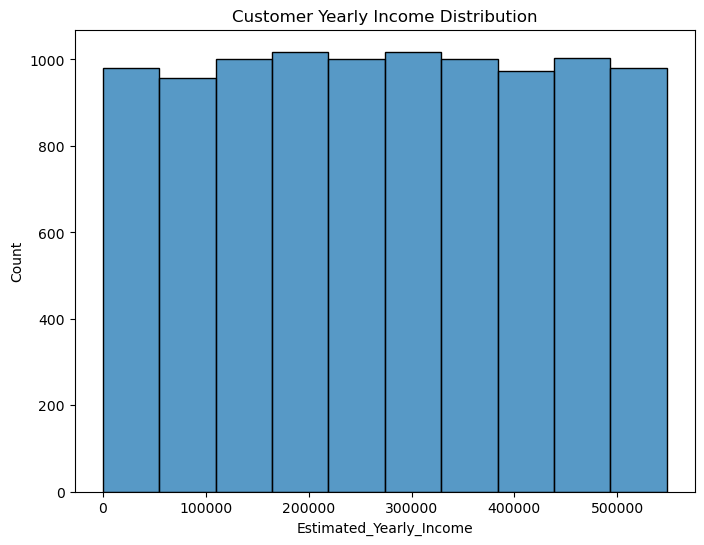

In [36]:
# Income Distribution analysis

plt.figure(figsize=(8,6))
sns.histplot(x='Estimated_Yearly_Income', data=df,bins =10)
plt.title("Customer Yearly Income Distribution")
    
plt.show()

### Insight :

Customer income is widely distributed across different ranges, suggesting a diverse customer base with varying financial capacities.

C:\Users\anujm\AppData\Local\Temp\ipykernel_14300\966662156.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  gd= sns.countplot(x='Gender', data=df,palette="Set3")


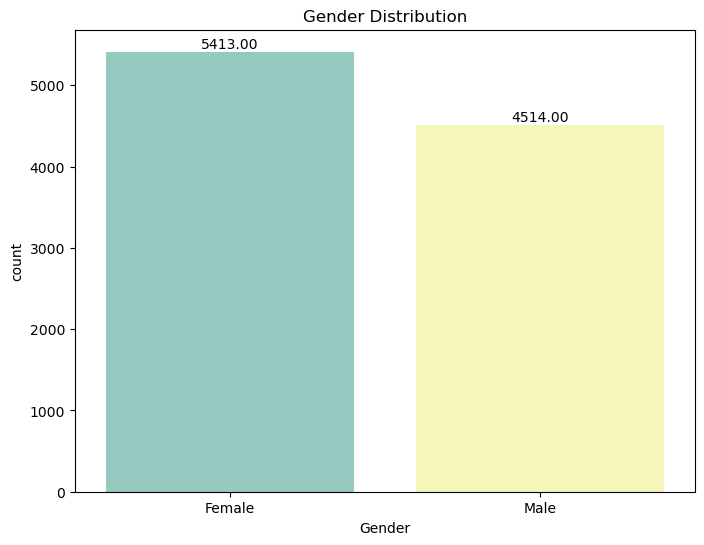

In [37]:
# Gender Distribution analysis

plt.figure(figsize=(8,6))
gd= sns.countplot(x='Gender', data=df,palette="Set3")
plt.title("Gender Distribution")

for i in gd.containers:
    gd.bar_label(i,fmt="%.2f")
    
plt.show()

### Insight :

The dataset shows a relatively balanced distribution between male and female customers, indicating no major gender skew.

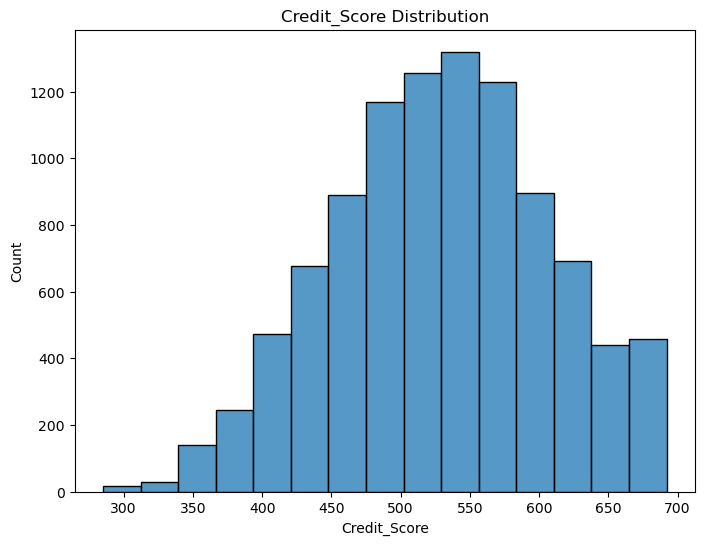

In [38]:
# credit score Distribution analysis

plt.figure(figsize=(8,6))
sns.histplot(x='Credit_Score', data=df,bins =15)
plt.title("Credit_Score Distribution")
    
plt.show()

### Insight :

Most customers have a moderate credit score range, indicating an average risk profile across the customer base.

C:\Users\anujm\AppData\Local\Temp\ipykernel_14300\260738492.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  cd= sns.countplot(x='City', data=df,palette="Set1")


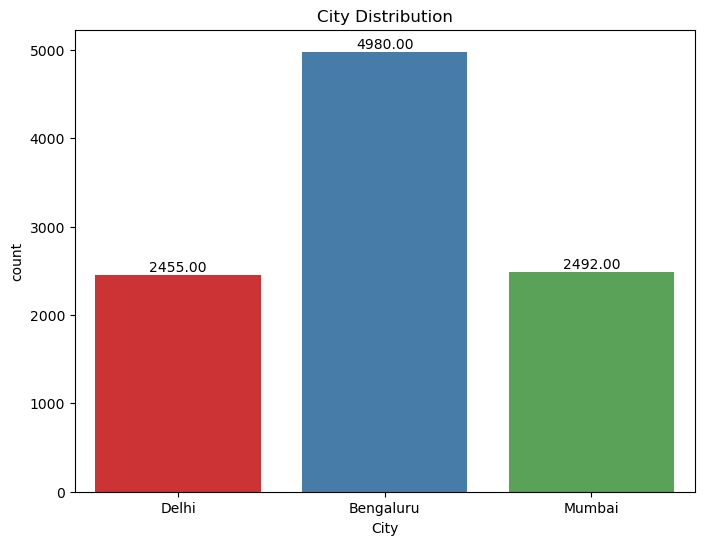

In [39]:
# City Distribution analysis

plt.figure(figsize=(8,6))
cd= sns.countplot(x='City', data=df,palette="Set1")
plt.title("City Distribution")

for i in cd.containers:
    cd.bar_label(i,fmt="%.2f")
    
plt.show()

### Insight :

Bengaluru has the highest number of customers, followed by Mumbai and Delhi, indicating stronger market presence in Bengaluru.

## bivariate analysis

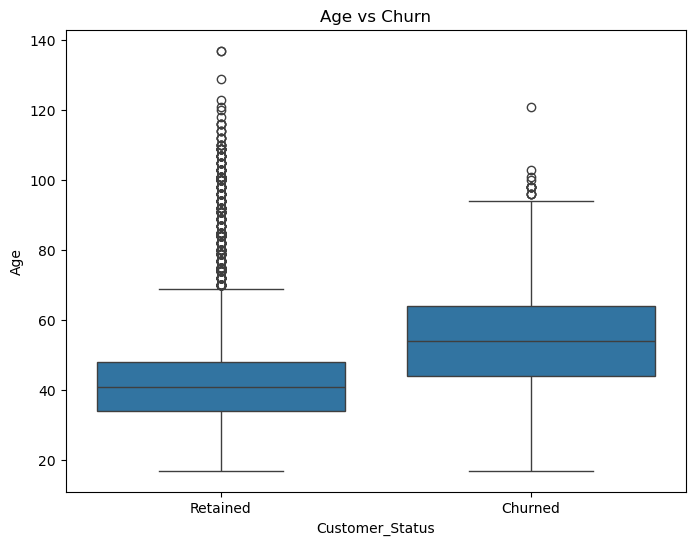

In [40]:
# AGE VS CHURN

plt.figure(figsize=(8,6))
sns.boxplot(x='Customer_Status', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

### INSIGHT:

Older customers show higher churn rates, suggesting the need for age-specific retention strategies.

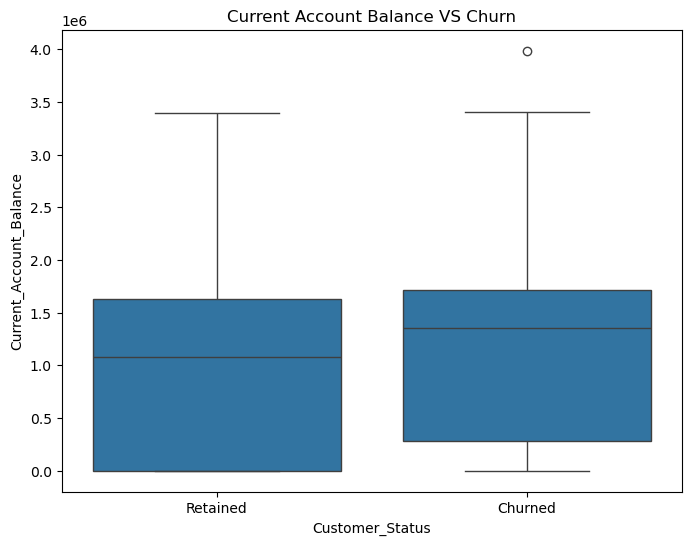

In [41]:
# Current Account Balance VS Churn

plt.figure(figsize=(8,6))
sns.boxplot(x='Customer_Status', y='Current_Account_Balance', data=df)
plt.title("Current Account Balance VS Churn")
plt.show()

### INSIGHT:

High-balance customers are more likely to churn, making them a critical segment for retention due to their high value.

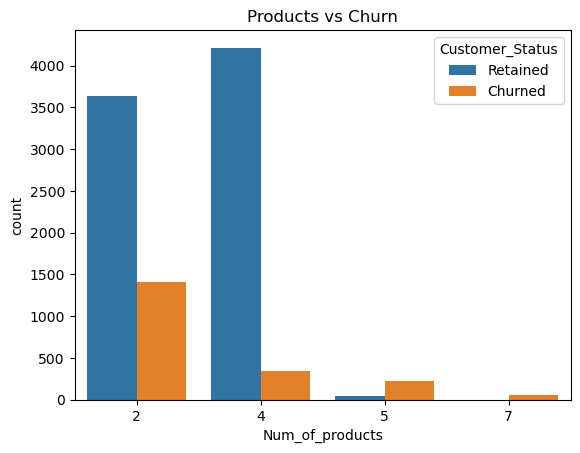

In [42]:
# PRODUCTS VS CHURN

sns.countplot(x='Num_of_products', hue='Customer_Status', data=df)
plt.title("Products vs Churn")
plt.show()

### INSIGHT:

Customers with fewer products are more likely to churn, highlighting the importance of cross-selling strategies..

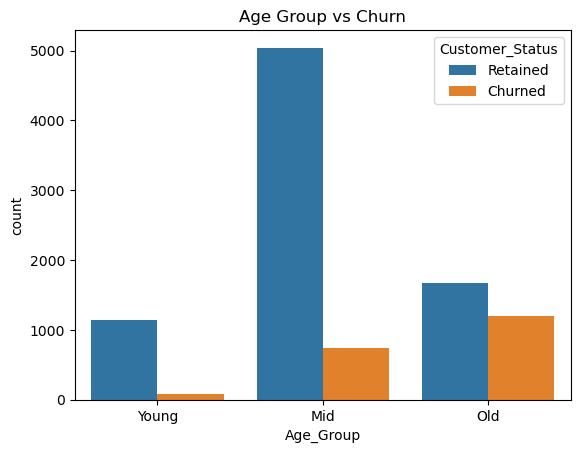

In [43]:
sns.countplot(x='Age_Group', hue='Customer_Status', data=df)
plt.title("Age Group vs Churn")
plt.show()

### Insight:

Customers in the middle-aged and older segments show higher churn tendencies, making them key focus groups for retention strategies.

## multivariate analysis

<function matplotlib.pyplot.show(close=None, block=None)>

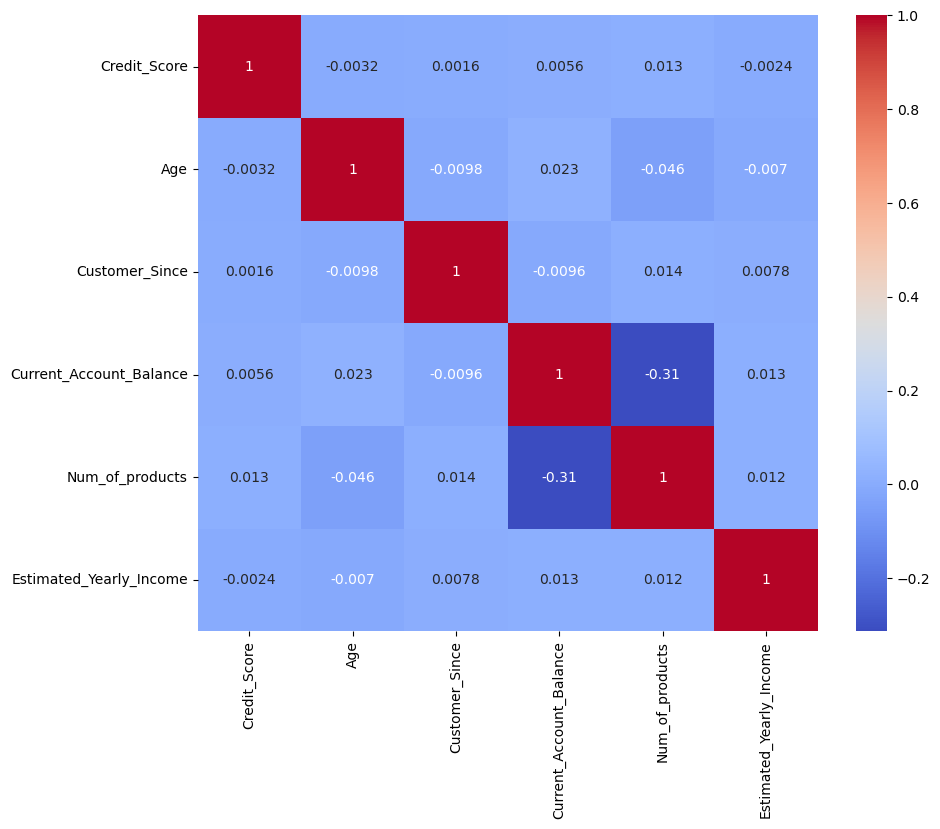

In [44]:
# CORRELATION

plt.figure(figsize=(10,8))
num_cols= df.select_dtypes(include = ["int64","float64"])
num_cols = num_cols.corr()
sns.heatmap(num_cols,cmap="coolwarm",annot=True)
plt.show

### INSIGHT:

The correlation matrix shows that most variables have weak linear relationships with each other, indicating that churn is influenced by multiple factors rather than a single dominant variable.

## FINAL BUSINESS INSIGHTS
- High-value customers (high balance) are more likely to churn
- Customers with fewer products show higher churn
- Older customers have higher churn tendency
- Low engagement (UPI inactive) customers churn more
- Bengaluru has highest customer base but churn exists across all regions

In [45]:
df.to_csv("amex_cleaned.csv", index=False)